# 07 - NYC Dispensary Opening Event Study

Within-NYC analysis: does a new cannabis dispensary opening affect 311 complaint patterns in the surrounding zip codes?

In [1]:
from pathlib import Path
DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

nyc_311 = pd.read_parquet(DATA_DIR / "nyc_311_zip_month.parquet")
disp    = pd.read_parquet(DATA_DIR / "nyc_dispensary_events.parquet")
print(f"311 panel: {nyc_311.shape}  |  Dispensaries: {len(disp)}")

311 panel: (8343, 8)  |  Dispensaries: 51


## Merge dispensary opening events onto 311 panel

In [2]:
# first_open_month, has_dispensary, post_open, and rel_month
# are already pre-merged in the panel parquet.
# Just set the event window size.
WINDOW = 12

print(f"Zip codes with dispensary: {nyc_311[['zip','has_dispensary']].drop_duplicates()['has_dispensary'].sum()}")
print(f"Zip codes without: {(~nyc_311[['zip','has_dispensary']].drop_duplicates()['has_dispensary']).sum()}")
print(f"Total months in panel: {nyc_311['month'].nunique()}")
print(f"Date range: {nyc_311['month'].min()} → {nyc_311['month'].max()}")


Zip codes with dispensary: 43
Zip codes without: 192
Total months in panel: 42
Date range: 2022-01 → 2025-06


## Event study: 311 complaints around dispensary opening

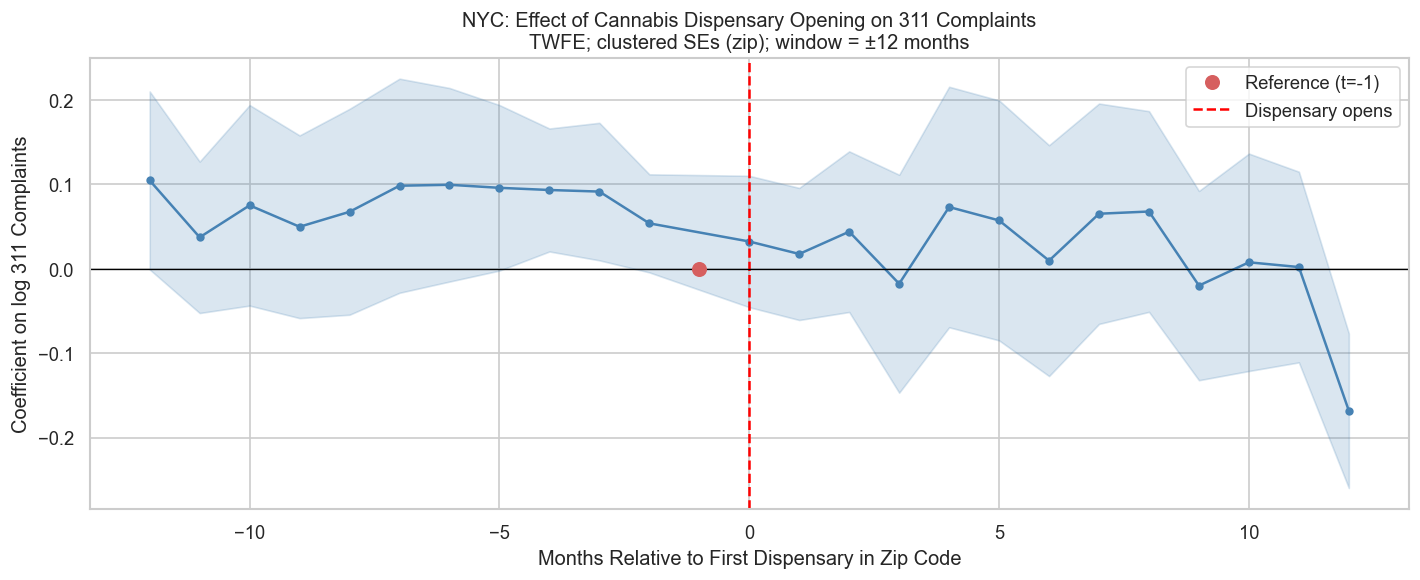

In [3]:
from linearmodels.panel import PanelOLS

outcome = 'log_total_complaints'
WINDOW = 12
ALL_PERIODS = [k for k in range(-WINDOW, WINDOW+1) if k != -1]

for k in ALL_PERIODS:
    nyc_311[f"dum_{k}"] = (
        nyc_311['has_dispensary'] &
        (nyc_311['rel_month'].fillna(9999).clip(-WINDOW, WINDOW) == k)
    ).astype(float)

dum_cols = [f"dum_{k}" for k in ALL_PERIODS]

# linearmodels requires numeric or datetime time index — convert Period to int
nyc_311['month_int'] = nyc_311['month'].apply(lambda p: p.ordinal)
nyc_idx = nyc_311.set_index(['zip', 'month_int'])

es_res = PanelOLS(
    nyc_idx[outcome],
    nyc_idx[dum_cols],
    entity_effects=True,
    time_effects=True,
).fit(cov_type='clustered', cluster_entity=True)

es_df = pd.DataFrame({
    'rel_month': ALL_PERIODS,
    'coef':  es_res.params[dum_cols].values,
    'ci_lo': es_res.conf_int().loc[dum_cols, 'lower'].values,
    'ci_hi': es_res.conf_int().loc[dum_cols, 'upper'].values,
}).sort_values('rel_month')

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(es_df['rel_month'], es_df['ci_lo'], es_df['ci_hi'], alpha=0.2, color='steelblue')
ax.plot(es_df['rel_month'], es_df['coef'], 'o-', ms=4, lw=1.5, color='steelblue')
ax.plot(-1, 0, 'ro', ms=8, zorder=5, label='Reference (t=-1)')
ax.axvline(0, color='red', ls='--', lw=1.5, label='Dispensary opens')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Months Relative to First Dispensary in Zip Code")
ax.set_ylabel("Coefficient on log 311 Complaints")
ax.set_title("NYC: Effect of Cannabis Dispensary Opening on 311 Complaints\nTWFE; clustered SEs (zip); window = ±12 months")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "07_nyc_dispensary_event_study.png", bbox_inches='tight')
plt.show()


## Interpretation — a within-city natural experiment

This design exploits *within-NYC* variation: dispensaries open in different zip
codes at different times (April 2024 onward), so zips that have not yet received
a dispensary serve as controls for those that have. With zip and month fixed
effects, identification comes from the timing of openings relative to each
neighborhood's own complaint trend.

**Reading the event study:** flat pre-opening leads support the assumption that
dispensary placement is not driven by pre-existing complaint trajectories
(if operators systematically opened in already-deteriorating neighborhoods, the
leads would slope). Post-opening lags then describe whether a dispensary shifts
local 311 activity — the policy-relevant quantity for the "dispensaries bring
disorder" debate.

**Caveats specific to this sample.** (1) NYC's permanent OCM retail licenses only
begin in 2024, so the post-period is short and the later cohorts have few
post-months — estimates at long event times rest on the early openers. (2) Zip
codes are coarse and dispensary catchment areas overlap, so SUTVA is imperfect;
spillover to adjacent zips would bias toward zero. The clean takeaway is the
*design* — a staggered within-city event study on real 311 and licensing data —
more than a precise long-run magnitude.